# INIT


In [2]:
# ==========================================
# CELLA 1: IMPORT LIBRERIE E SETUP
# ==========================================
import scipy.stats as stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from pyvis.network import Network
import warnings
from itertools import combinations

# Ignoriamo i warning sui dtypes misti per letture veloci
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")

✅ Librerie caricate con successo. Ambiente pronto.


In [3]:
TARGET_GENE = 'KRAS'

COORTI = {
    "kras_pancreas": "./data_filtered/kras_pancreas",
    "kras_lung": "./data_filtered/kras_lung",
    "kras_colon": "./data_filtered/kras_colon",
    "pancreas": "./data_filtered/pancreas",
    "lung": "./data_filtered/lung",
    "colon": "./data_filtered/colon",
}

# MODIFICA: Nuova cartella di output per SV
OUTPUT_BASE_DIR = "./outputs_mut"

COOCC_PARAMS = {
    "kras_pancreas": {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3},
    "kras_lung":     {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3},
    "kras_colon":    {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3},
    "pancreas": {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3},
    "lung":     {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3},
    "colon":    {"p_val": 0.05, "log2or": 2.0, "min_cooc": 3}
}

ME_PARAMS = {
    "kras_pancreas": {"p_val": 0.01, "log2or": -1.0},
    "kras_lung":     {"p_val": 0.01, "log2or": -1.0},
    "kras_colon":    {"p_val": 0.01, "log2or": -1.0},
    "pancreas": {"p_val": 0.01, "log2or": -1.0},
    "lung":     {"p_val": 0.01, "log2or": -1.0},
    "colon":    {"p_val": 0.01, "log2or": -1.0}
}

print("⚙️ Parametri globali configurati per Structural Variants (SV).")

⚙️ Parametri globali configurati per Structural Variants (SV).


# ENRICHMENT PER OGNI CLUSTER


In [4]:
# ==========================================
# CELLA: ENRICHMENT ANALYSIS AUTOMATICA CON GSEAPY E SALVATAGGIO REPORT
# ==========================================
import pandas as pd
import gseapy as gp
import os
import time

def run_cluster_enrichment(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per il nome dei file e dei titoli
    net_type = "FULL" if is_full else f"FILTRATA_{target_gene}"
    print(f"\n--- 🧬 AVVIO ENRICHMENT AUTOMATICO: {cohort_name.upper()} ({net_type}) ---")
    
    # 1. Trova il file dei cluster generato in precedenza
    cluster_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    cluster_file = f"{cluster_dir}/Cluster_Genes_{net_type}_{cohort_name}.tsv"
    
    if not os.path.exists(cluster_file):
        print(f"[!] File cluster non trovato: {cluster_file}")
        return
        
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    
    # Database biologici
    databases = [
        'KEGG_2021_Human', 
        'GO_Biological_Process_2021', 
        'GO_Cellular_Component_2021', 
        'GO_Molecular_Function_2021'
    ]
    
    all_results = []
    cluster_ids = df_clusters['Cluster_ID'].unique()
    
    for c_id in cluster_ids:
        genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        # Saltiamo i cluster troppo piccoli (l'enrichment richiede un minimo di geni)
        if len(genes) < 4:
            continue
            
        print(f"Analizzo Cluster {c_id} ({len(genes)} geni)...")
        
        try:
            # Interroghiamo Enrichr
            enr = gp.enrichr(gene_list=genes, gene_sets=databases, organism='human', outdir=None) 
            res_df = enr.results
            sig_res = res_df[res_df['P-value'] < 0.05].copy()
            
            if not sig_res.empty:
                sig_res['Cluster_ID'] = c_id
                all_results.append(sig_res)
                
            # Piccola pausa per non farci bloccare dal server di Enrichr per troppe richieste
            time.sleep(1)
        except Exception as e:
            print(f"Errore nel Cluster {c_id}: {e}")
            
    # 4. SALVATAGGIO DATI COMPLETI E REPORT TESTUALE
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        cols = ['Cluster_ID', 'Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']
        final_df = final_df[cols].sort_values(by=['Cluster_ID', 'P-value'], ascending=[True, True])
        
        # Salva la tabella Excel/TSV completa (per eventuali grafici futuri)
        out_file_tsv = f"{cluster_dir}/Enrichment_Results_{net_type}_{cohort_name}.tsv"
        final_df.to_csv(out_file_tsv, sep='\t', index=False)
        print(f"✅ Analisi completata! Tabella dati salvata in: {out_file_tsv}")
        
        # --- CREAZIONE DEL FILE DI TESTO (REPORT PER IL PROF) ---
        out_file_txt = f"{cluster_dir}/Report_Prof_Top3_Enrichment_{net_type}_{cohort_name}.txt"
        
        # Apriamo il file in modalità scrittura ('w')
        with open(out_file_txt, 'w', encoding='utf-8') as f:
            
            titolo = f"--- 🏆 TOP 3 PATHWAY/ONTOLOGY PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
            print(f"\n{titolo}")
            f.write(f"{titolo}\n")
            
            for c_id in final_df['Cluster_ID'].unique():
                cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
                genes_str = ", ".join(cluster_genes)
                
                # Prepariamo le stringhe per l'intestazione del cluster
                sep = "="*80
                head1 = f"🎯 CLUSTER {c_id}  |  DIMENSIONE: {len(cluster_genes)} geni"
                head2 = f"🧬 TUTTI I GENI: {genes_str}"
                
                # Stampiamo a video
                print(f"\n{sep}\n{head1}\n{head2}\n{sep}")
                # Scriviamo nel file
                f.write(f"\n{sep}\n{head1}\n{head2}\n{sep}\n")
                
                top_3 = final_df[final_df['Cluster_ID'] == c_id].head(3)
                
                for index, row in top_3.iterrows():
                    # Prepariamo le stringhe per i pathway
                    path_title = f"🔸 [{row['Gene_set']}] {row['Term']}"
                    path_stats = f"   P-value: {row['P-value']:.2e}  |  Overlap: {row['Overlap']}"
                    path_genes = f"   🎯 Geni nel pathway: {row['Genes']}"
                    
                    # Stampiamo a video
                    print(f"\n{path_title}\n{path_stats}\n{path_genes}")
                    # Scriviamo nel file
                    f.write(f"\n{path_title}\n{path_stats}\n{path_genes}\n")
                    
        print(f"\n📄 REPORT DI TESTO PER IL PROF SALVATO IN: {out_file_txt}\n")
            
    else:
        print("[-] Nessun pathway significativo trovato per questi cluster.\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        # Rete 3: Mappa globale dei soli pazienti mutati
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        # Rete 1: Mappa globale di tutti i pazienti
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True)
        
        # Rete 2: Zoom specifico su KRAS
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=False)

print("\n🎉 TUTTE LE ANALISI DI ENRICHMENT SONO STATE COMPLETATE CON SUCCESSO!")


--- 🧬 AVVIO ENRICHMENT AUTOMATICO: KRAS_PANCREAS (FULL) ---
Analizzo Cluster 0 (10 geni)...
Analizzo Cluster 1 (6 geni)...
Analizzo Cluster 2 (7 geni)...
Analizzo Cluster 3 (14 geni)...
Analizzo Cluster 4 (11 geni)...
Analizzo Cluster 5 (11 geni)...
Analizzo Cluster 6 (7 geni)...
✅ Analisi completata! Tabella dati salvata in: ./outputs_mut/kras_pancreas/networks/Enrichment_Results_FULL_kras_pancreas.tsv

--- 🏆 TOP 3 PATHWAY/ONTOLOGY PER OGNI CLUSTER (KRAS_PANCREAS - FULL) ---

🎯 CLUSTER 0  |  DIMENSIONE: 10 geni
🧬 TUTTI I GENI: CASP8, HIST1H1C, SETD2, FANCA, AKT3, SMAD4, CTCF, PGR, GATA1, KMT2A

🔸 [GO_Molecular_Function_2021] transcription coregulator binding (GO:0001221)
   P-value: 2.08e-06  |  Overlap: 3/53
   🎯 Geni nel pathway: SMAD4;PGR;CTCF

🔸 [GO_Biological_Process_2021] regulation of histone H3-K9 acetylation (GO:2000615)
   P-value: 1.23e-05  |  Overlap: 2/11
   🎯 Geni nel pathway: SMAD4;KMT2A

🔸 [GO_Biological_Process_2021] positive regulation of histone H3-K4 methylation (

# ANALISI INTRACLUSTER


In [5]:
# ==========================================
# CELLA 8: ANALISI DELLE METRICHE TOPOLOGICHE INTRACLUSTER
# ==========================================
import pandas as pd
import networkx as nx
import os

def analyze_intracluster_metrics(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per l'output
    net_type = "FULL" if is_full else f"FILTRATA_{target_gene}"
    print(f"\n" + "="*70)
    print(f"📊 METRICHE INTRACLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*70)

    # 1. Definizione percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    stats_file = f"{base_dir}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    cluster_file = f"{base_dir}/networks/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(cluster_file):
        print(f"[!] File mancanti per l'analisi di {cohort_name} ({net_type}).")
        return

    # 2. Ricostruzione della Rete originale (per calcolare gli archi)
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    # Recupero soglie per ricostruire esattamente la rete
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    # Selezione tra FULL e FILTRATA
    if is_full:
        G_work = G_full
    else:
        if target_gene in G_full.nodes():
            neighbors = list(G_full.neighbors(target_gene))
            G_work = G_full.subgraph(neighbors + [target_gene]).copy()
        else:
            print(f"[!] Target {target_gene} non presente nella rete, salto calcolo.")
            return

    # 3. Caricamento dei Cluster
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    cluster_ids = sorted(df_clusters['Cluster_ID'].unique())

    metrics_list = []

    # 4. Calcolo Metriche per ogni singolo cluster
    for c_id in cluster_ids:
        # Estraiamo i geni del cluster che sono effettivamente nella rete
        cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        valid_genes = [g for g in cluster_genes if g in G_work.nodes()]
        
        # Se un cluster ha meno di 2 nodi, le metriche topologiche non hanno senso
        if len(valid_genes) < 2:
            continue
            
        # Creiamo il sottografo contenente SOLO i geni di questo cluster
        subG = G_work.subgraph(valid_genes)
        
        n_nodes = subG.number_of_nodes()
        n_edges = subG.number_of_edges()
        
        # Calcolo Metriche
        density = nx.density(subG)
        avg_degree = (2 * n_edges) / n_nodes if n_nodes > 0 else 0
        avg_clustering = nx.average_clustering(subG, weight='weight')
        
        metrics_list.append({
            'Cluster_ID': c_id,
            'N_Nodes': n_nodes,
            'N_Edges': n_edges,
            'Density': round(density, 3),
            'Avg_Degree': round(avg_degree, 2),
            'Avg_Clustering': round(avg_clustering, 3)
        })

    # 5. Salvataggio e Stampa a video
    if metrics_list:
        df_metrics = pd.DataFrame(metrics_list)
        
        # Salva file TSV
        out_file = f"{base_dir}/networks/Intracluster_Metrics_{net_type}_{cohort_name}.tsv"
        df_metrics.to_csv(out_file, sep='\t', index=False)
        
        # Stampa una tabella formattata a video
        print(df_metrics.to_string(index=False))
        print(f"\n✅ Metriche salvate in: {out_file}\n")
    else:
        print("[-] Nessun cluster valido per calcolare le metriche.")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=False)

print("🎉 ANALISI DELLE METRICHE INTRACLUSTER COMPLETATA!")


📊 METRICHE INTRACLUSTER: KRAS_PANCREAS (FULL)
 Cluster_ID  N_Nodes  N_Edges  Density  Avg_Degree  Avg_Clustering
          0       10        9    0.200        1.80           0.000
          1        6        5    0.333        1.67           0.000
          2        7        6    0.286        1.71           0.000
          3       14       14    0.154        2.00           0.000
          4       11       12    0.218        2.18           0.136
          5       11       13    0.236        2.36           0.083
          6        7        6    0.286        1.71           0.000
          7        2        1    1.000        1.00           0.000

✅ Metriche salvate in: ./outputs_mut/kras_pancreas/networks/Intracluster_Metrics_FULL_kras_pancreas.tsv


📊 METRICHE INTRACLUSTER: KRAS_LUNG (FULL)
 Cluster_ID  N_Nodes  N_Edges  Density  Avg_Degree  Avg_Clustering
          0       17       23    0.169        2.71           0.149
          1       50       75    0.061        3.00           0.048


# ANALISI VARIE TECNICHE DI CLUSTERING



  🔬 CONFRONTO CLUSTERING — KRAS_PANCREAS
  Rete: 68 nodi, 89 archi

  ▶ Louvain... ✓  Q=0.593  k=8  sil=0.15  (0.0s)

  ▶ Leiden... ✓  Q=0.593  k=8  sil=0.15  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.572  k=9  sil=0.1658  (0.1s)

  ▶ Infomap... ✓  Q=0.590  k=10  sil=0.1872  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  8      0.5934      0.1500          1.0000       0.00
       Leiden  8      0.5934      0.1500          1.0000       0.00
Girvan-Newman  9      0.5718      0.1658          0.8002       0.08
      Infomap 10      0.5901      0.1872          0.8166       0.03
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_pancreas/networks/Clustering_Comparison_kras_pancreas.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


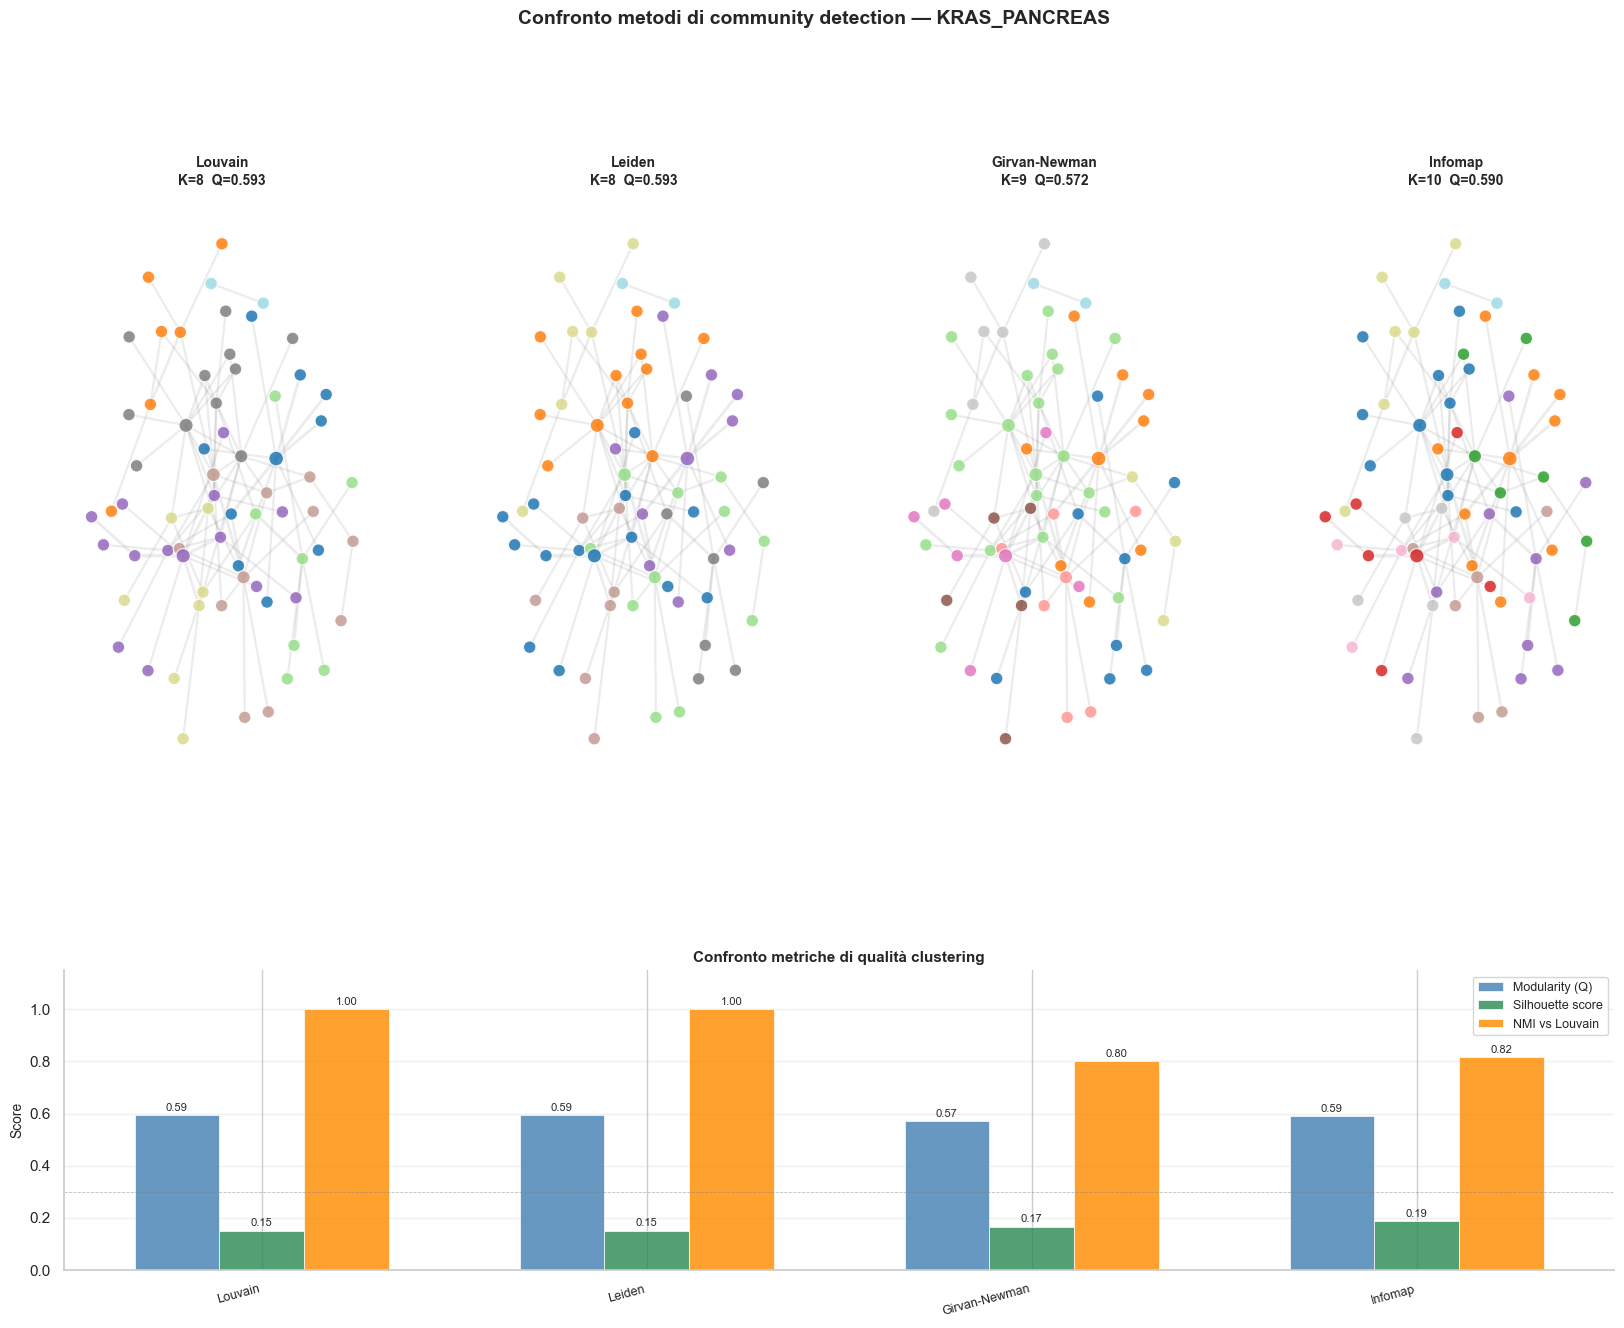

✅ Plot comparativo salvato: ./outputs_mut/kras_pancreas/networks/Clustering_Comparison_kras_pancreas.png

  🔬 CONFRONTO CLUSTERING — KRAS_LUNG
  Rete: 248 nodi, 756 archi

  ▶ Louvain... ✓  Q=0.425  k=9  sil=0.0461  (0.0s)

  ▶ Leiden... ✓  Q=0.432  k=9  sil=0.0511  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.124  k=12  sil=0.041  (8.3s)

  ▶ Infomap... ✓  Q=0.422  k=16  sil=0.0744  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  9      0.4253      0.0461          1.0000       0.01
       Leiden  9      0.4315      0.0511          0.4746       0.01
Girvan-Newman 12      0.1241      0.0410          0.2517       8.33
      Infomap 16      0.4220      0.0744          0.5539       0.00
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_lung/networks/Clustering_Comparison_kras_lung.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


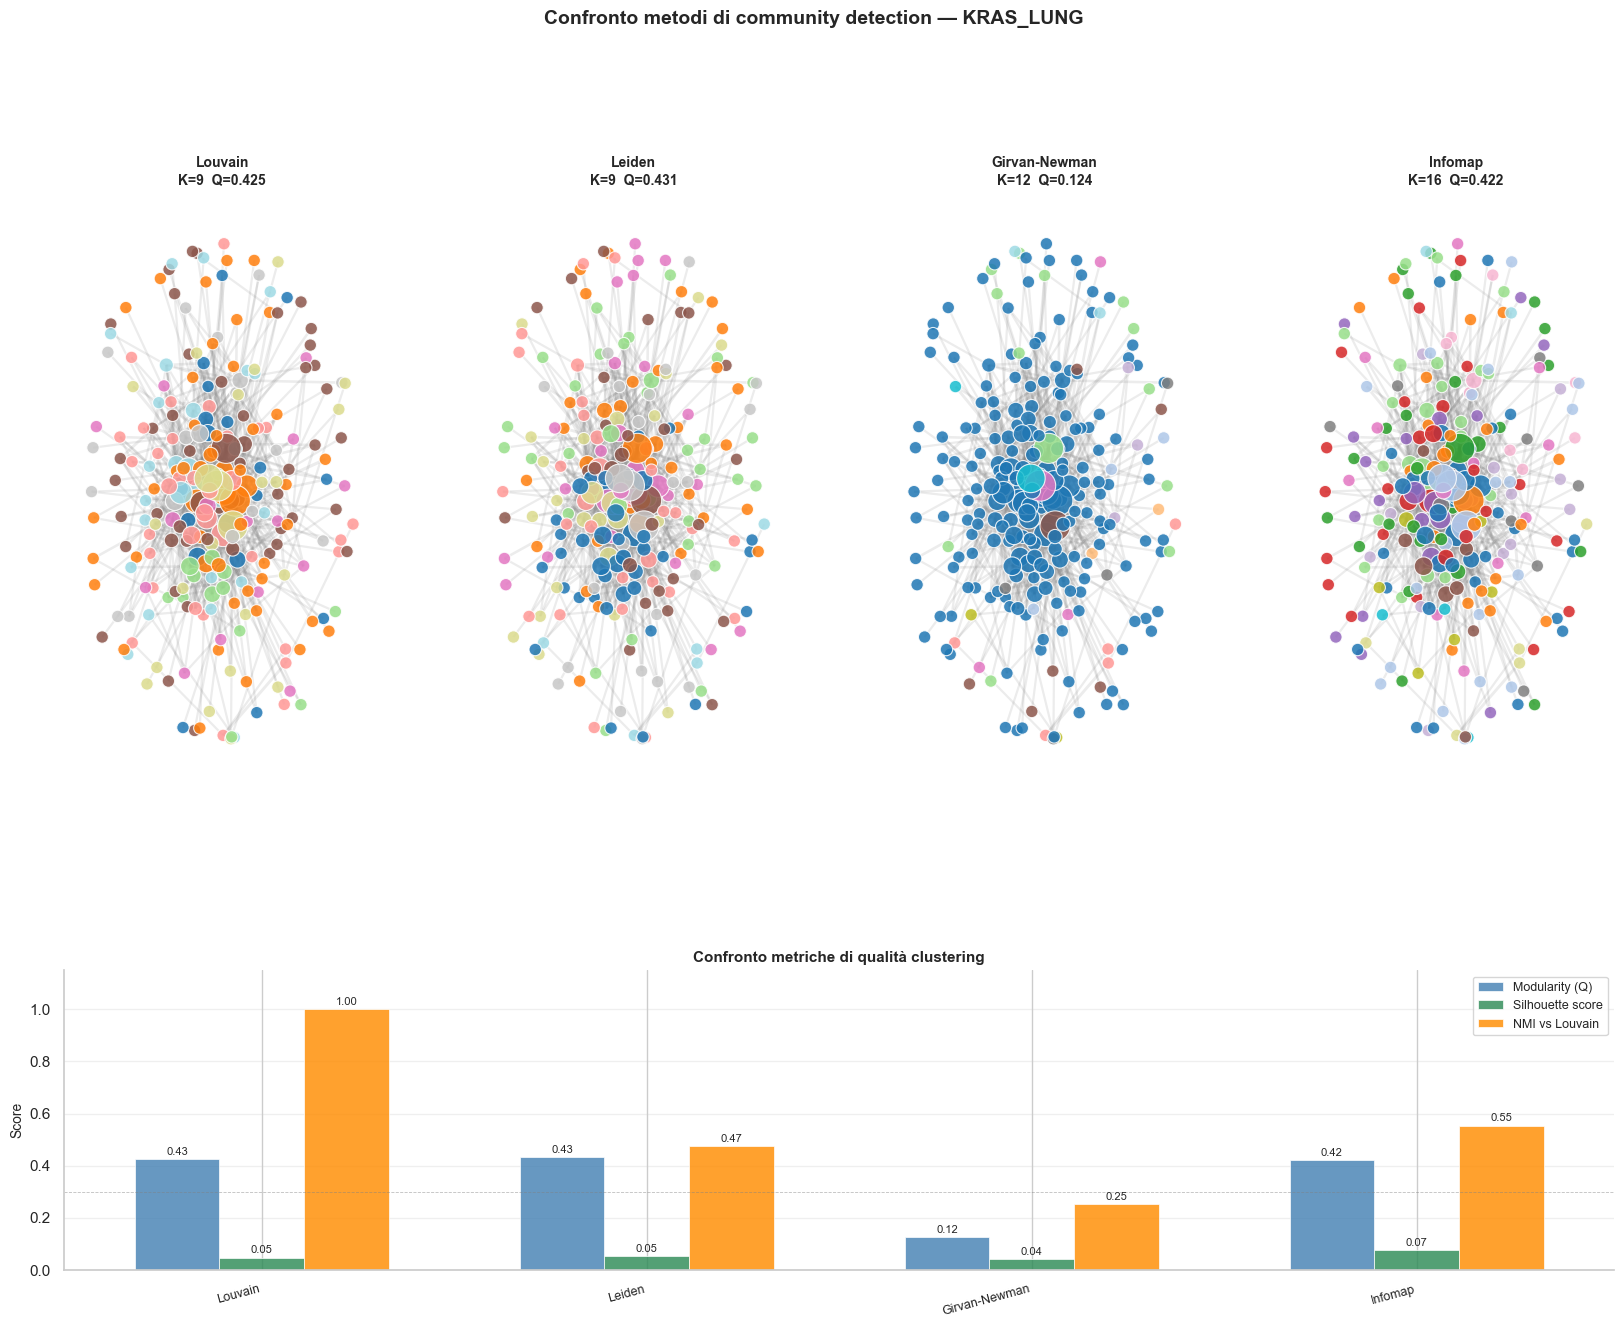

✅ Plot comparativo salvato: ./outputs_mut/kras_lung/networks/Clustering_Comparison_kras_lung.png

  🔬 CONFRONTO CLUSTERING — KRAS_COLON
  Rete: 280 nodi, 5749 archi

  ▶ Louvain... ✓  Q=0.153  k=5  sil=0.076  (0.0s)

  ▶ Leiden... ✓  Q=0.151  k=6  sil=0.088  (0.0s)

  ▶ Girvan-Newman... ✓  Q=-0.000  k=2  sil=0.1012  (10.2s)

  ▶ Infomap... ✓  Q=0.007  k=4  sil=0.0615  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  5      0.1527      0.0760          1.0000       0.03
       Leiden  6      0.1512      0.0880          0.4552       0.02
Girvan-Newman  2     -0.0000      0.1012          0.0062      10.23
      Infomap  4      0.0071      0.0615          0.0541       0.01
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/kras_colon/networks/Clustering_Comparison_kras_colon.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


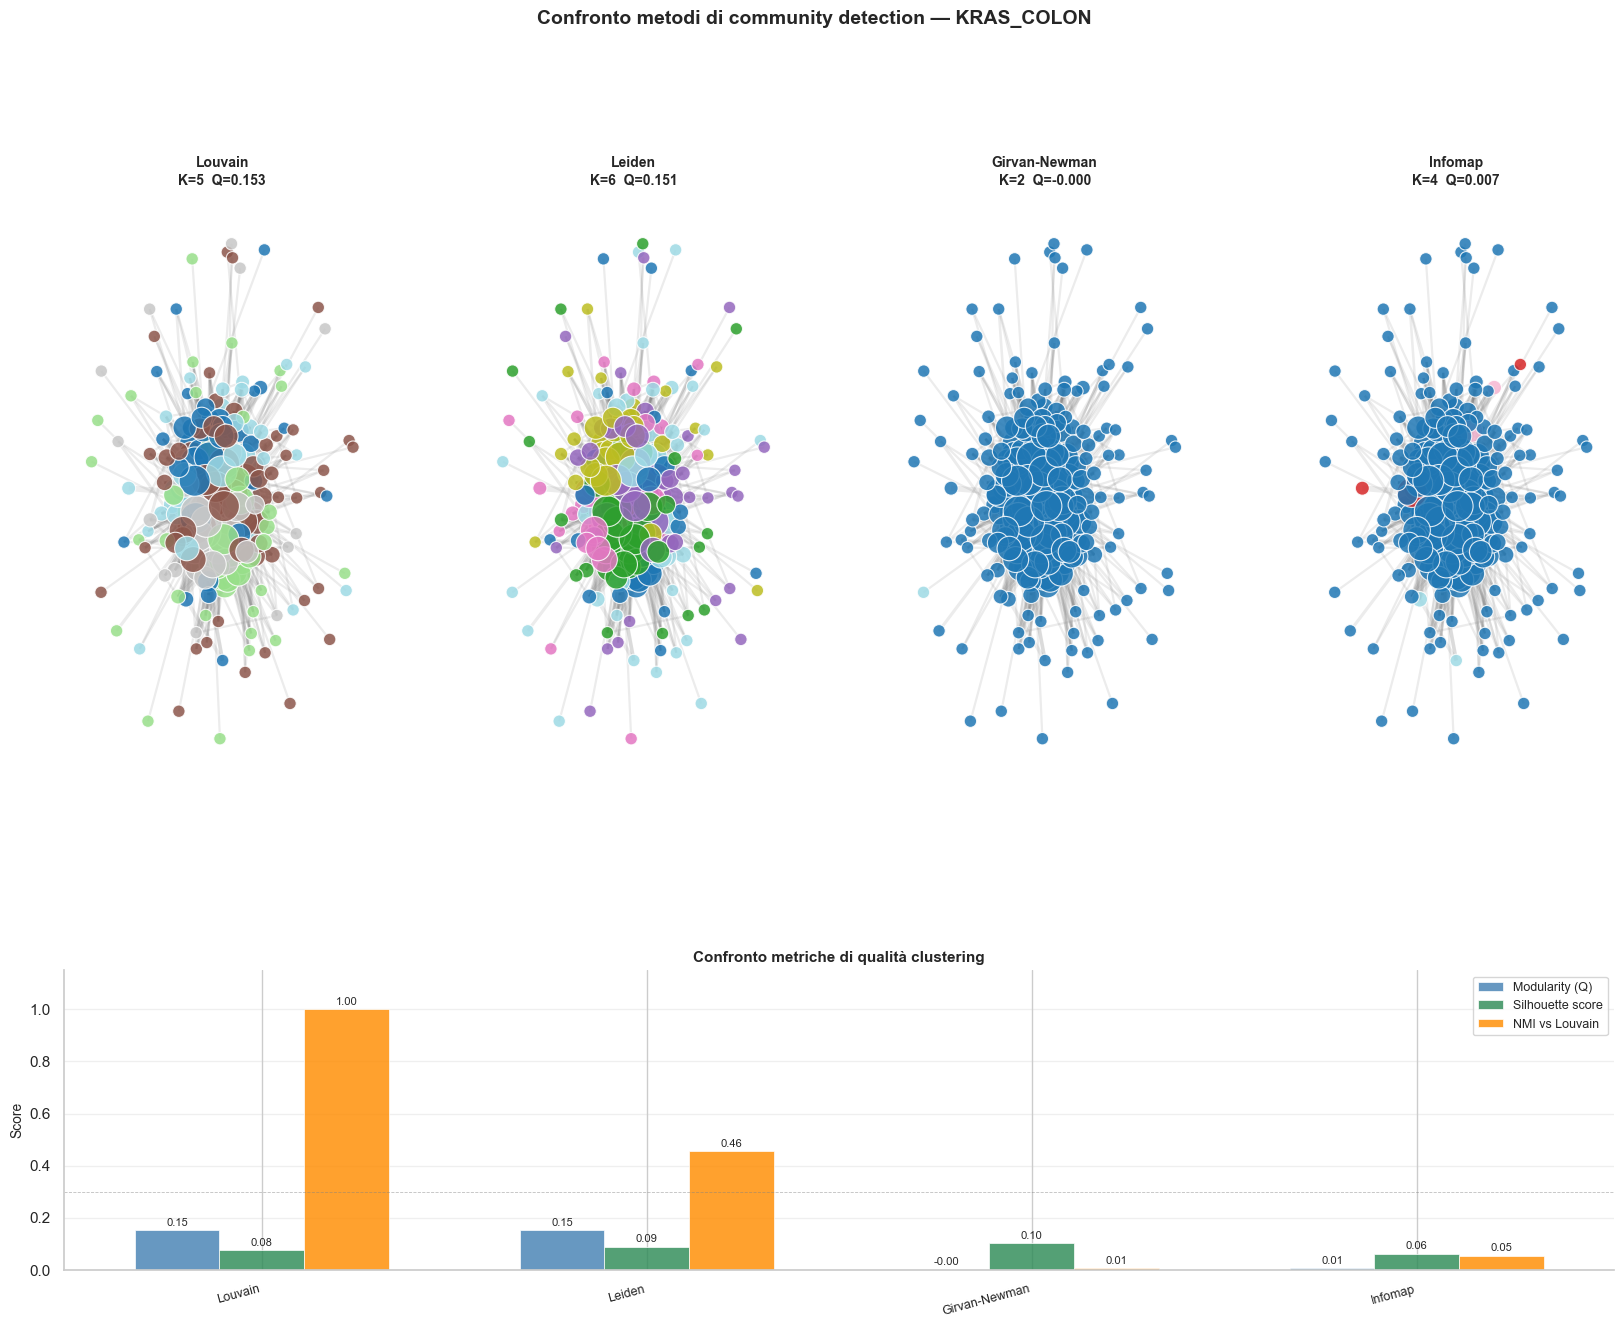

✅ Plot comparativo salvato: ./outputs_mut/kras_colon/networks/Clustering_Comparison_kras_colon.png

  🔬 CONFRONTO CLUSTERING — PANCREAS
  Rete: 101 nodi, 225 archi

  ▶ Louvain... ✓  Q=0.487  k=4  sil=0.077  (0.0s)

  ▶ Leiden... ✓  Q=0.487  k=4  sil=0.077  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.480  k=7  sil=0.1002  (0.5s)

  ▶ Infomap... ✓  Q=0.478  k=9  sil=0.1266  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  4      0.4872      0.0770          1.0000       0.00
       Leiden  4      0.4872      0.0770          1.0000       0.00
Girvan-Newman  7      0.4803      0.1002          0.8211       0.46
      Infomap  9      0.4776      0.1266          0.7388       0.00
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/pancreas/networks/Clustering_Comparison_pancreas.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


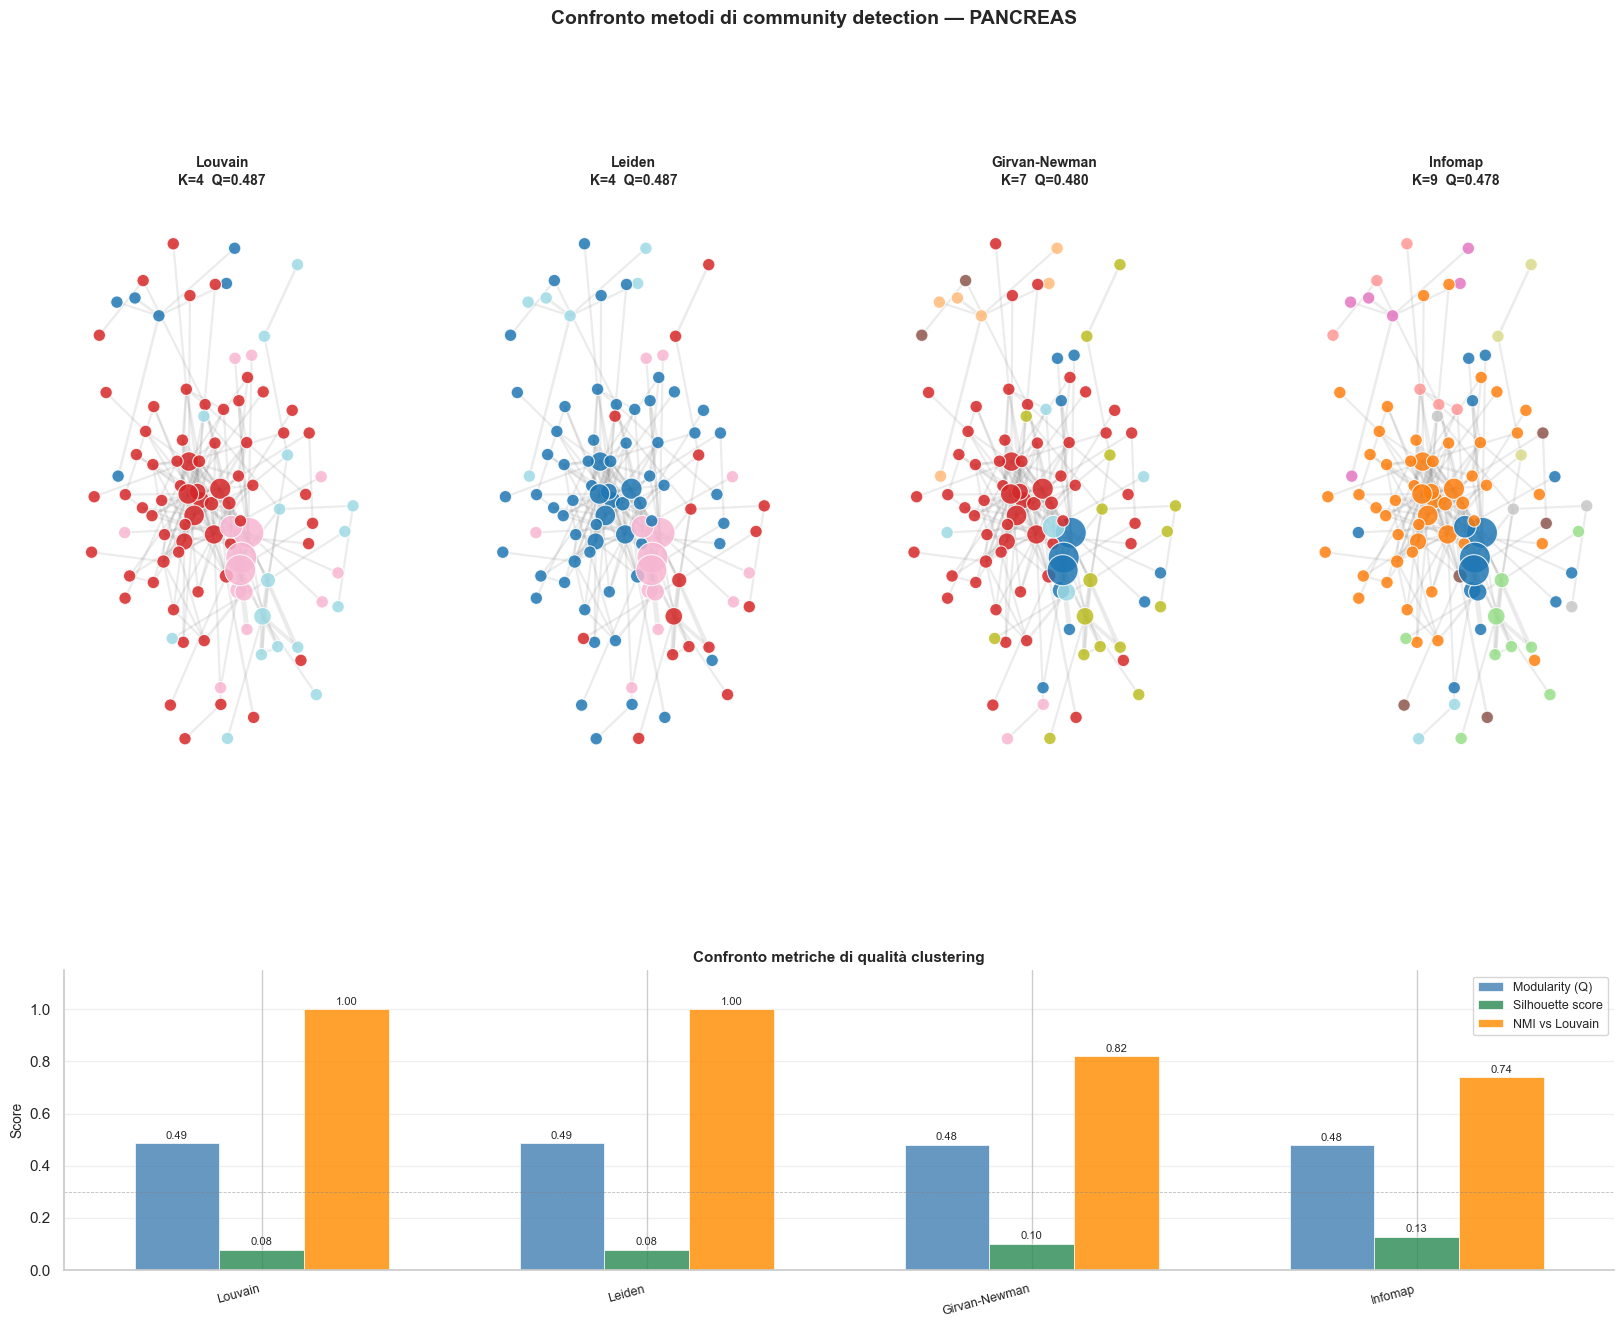

✅ Plot comparativo salvato: ./outputs_mut/pancreas/networks/Clustering_Comparison_pancreas.png

  🔬 CONFRONTO CLUSTERING — LUNG
  Rete: 436 nodi, 4838 archi

  ▶ Louvain... ✓  Q=0.204  k=8  sil=0.0313  (0.0s)

  ▶ Leiden... ✓  Q=0.211  k=9  sil=0.042  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.009  k=3  sil=0.039  (25.0s)

  ▶ Infomap... ✓  Q=0.047  k=8  sil=-0.0293  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  8      0.2045      0.0313          1.0000       0.03
       Leiden  9      0.2110      0.0420          0.3751       0.03
Girvan-Newman  3      0.0095      0.0390          0.0665      24.97
      Infomap  8      0.0469     -0.0293          0.1456       0.02
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/lung/networks/Clustering_Comparison_lung.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


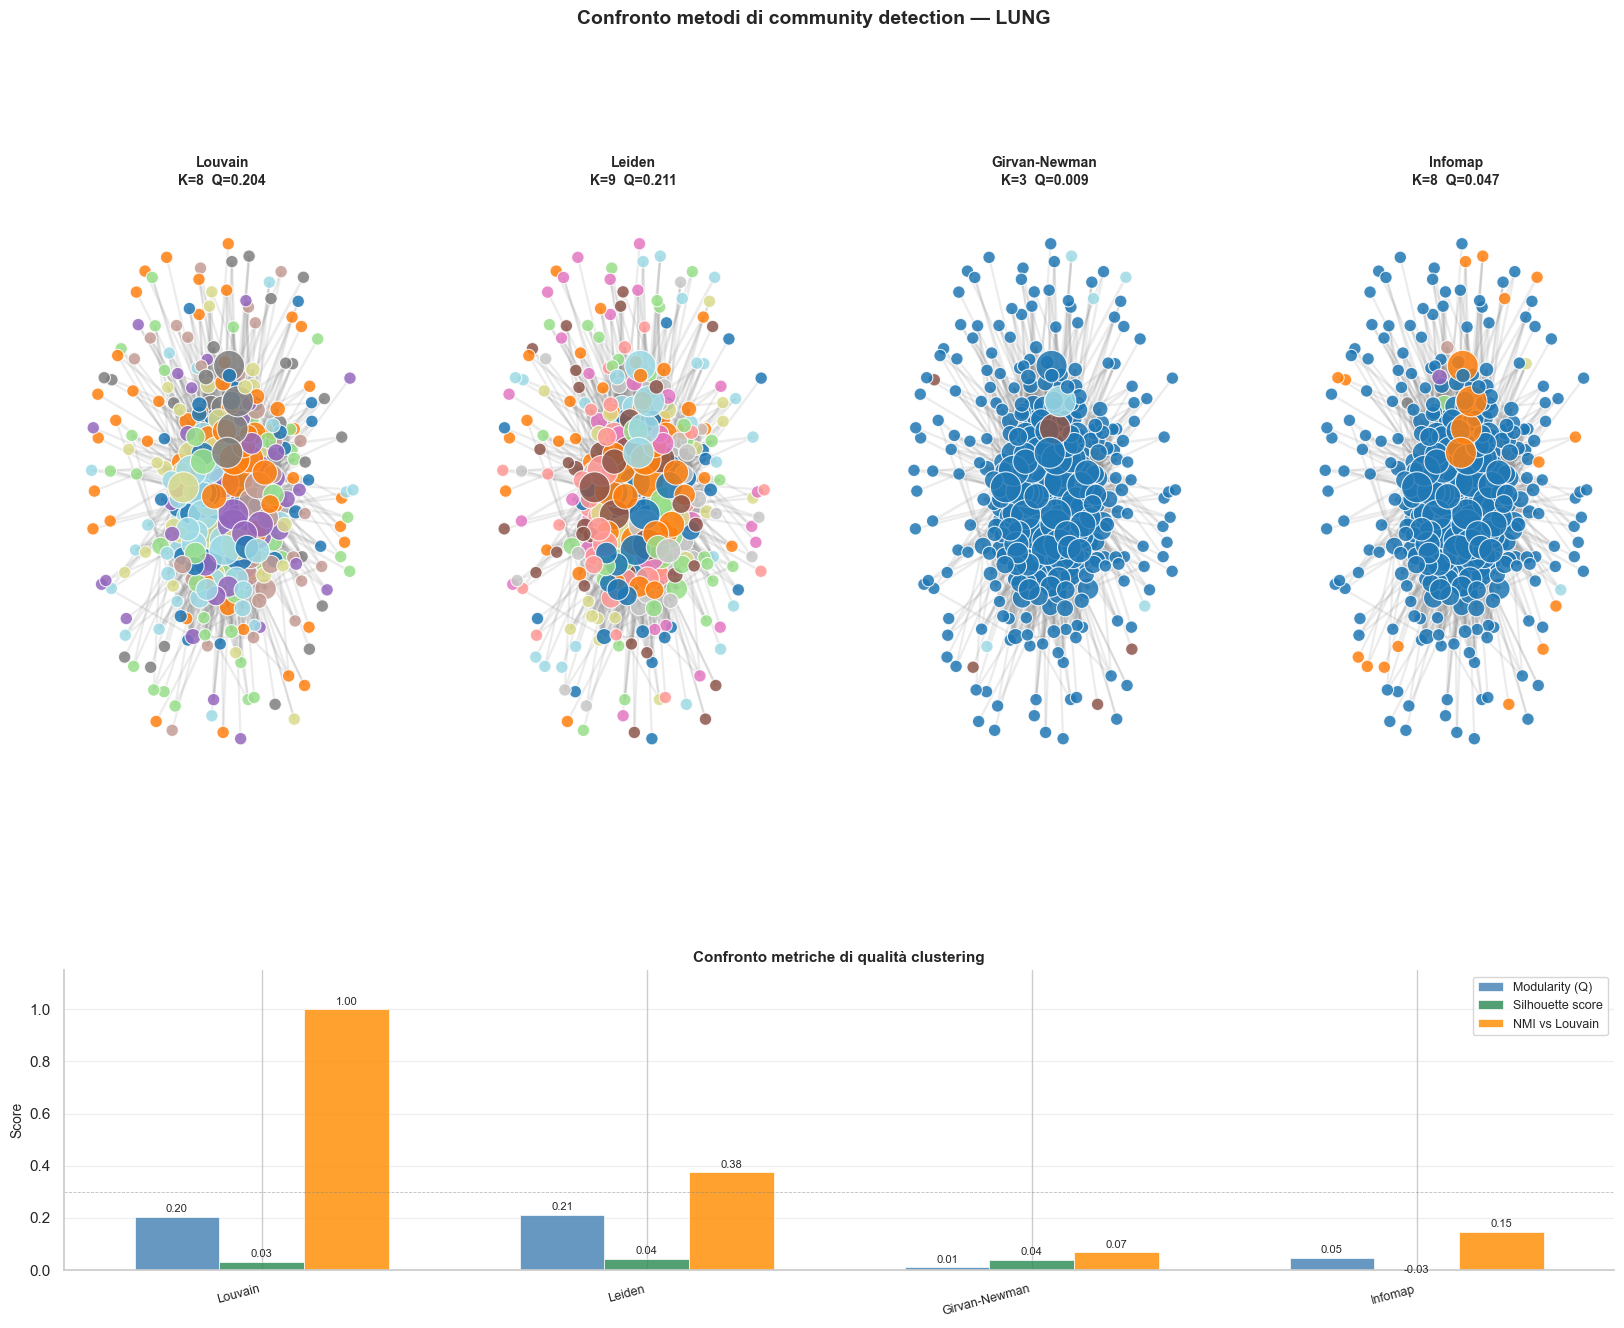

✅ Plot comparativo salvato: ./outputs_mut/lung/networks/Clustering_Comparison_lung.png

  🔬 CONFRONTO CLUSTERING — COLON
  Rete: 299 nodi, 5909 archi

  ▶ Louvain... ✓  Q=0.179  k=5  sil=0.0831  (0.0s)

  ▶ Leiden... ✓  Q=0.179  k=7  sil=0.1014  (0.0s)

  ▶ Girvan-Newman... ✓  Q=0.002  k=3  sil=0.0942  (14.8s)

  ▶ Infomap... ✓  Q=0.028  k=6  sil=0.0849  (0.0s)

───────────────────────────────────────────────────────
       Metodo  K  Modularity  Silhouette  NMI vs Louvain  Tempo (s)
      Louvain  5      0.1785      0.0831          1.0000       0.03
       Leiden  7      0.1792      0.1014          0.5689       0.02
Girvan-Newman  3      0.0025      0.0942          0.0724      14.81
      Infomap  6      0.0280      0.0849          0.1947       0.01
───────────────────────────────────────────────────────
📊 Tabella metriche salvata: ./outputs_mut/colon/networks/Clustering_Comparison_colon.tsv


/var/folders/bk/9ndm0rkn2sv5c7qws_f81k2c0000gn/T/ipykernel_89793/790420525.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


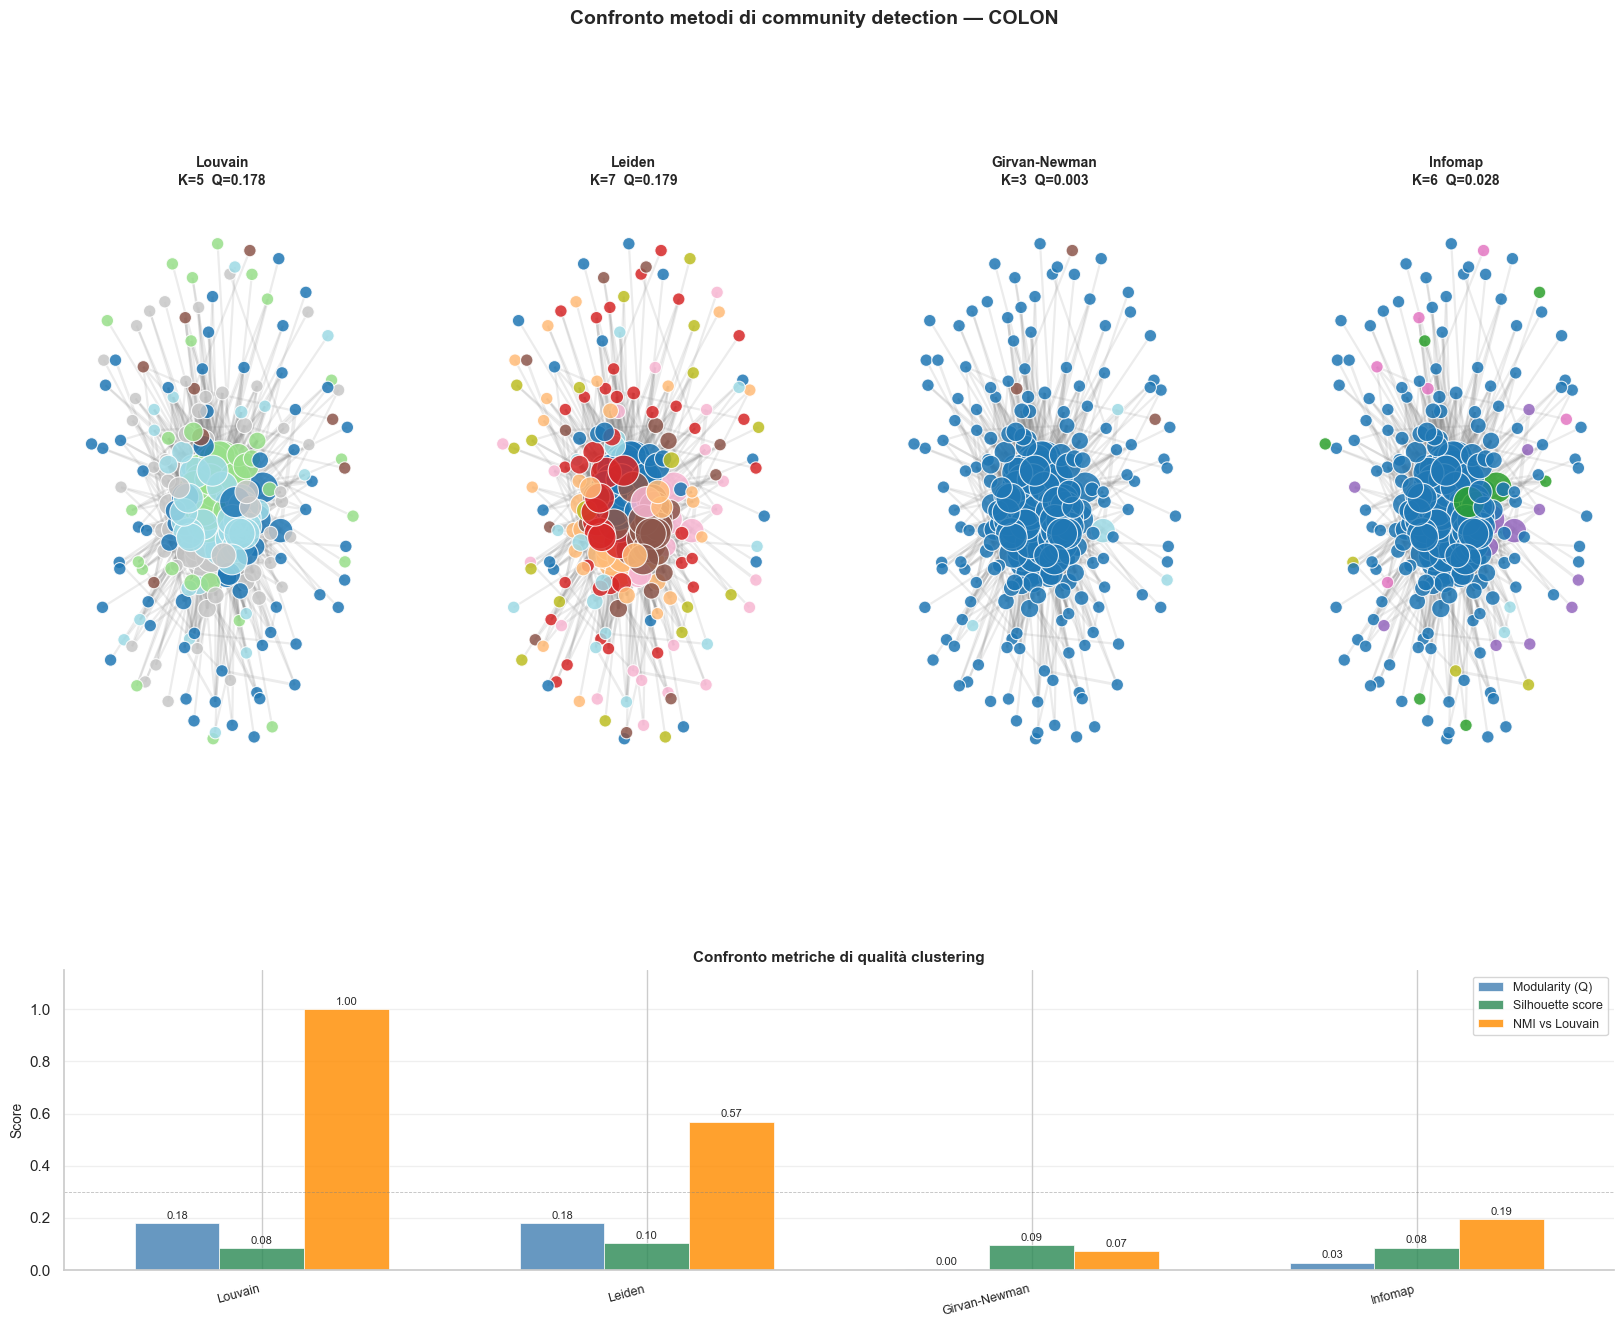

✅ Plot comparativo salvato: ./outputs_mut/colon/networks/Clustering_Comparison_colon.png

🏁 Confronto clustering completato per tutte le coorti.


In [ ]:
# ==========================================
# CONFRONTO METODI DI CLUSTERING
# ==========================================
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import time
import os
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score

# --- Dipendenze opzionali ---
try:
    import leidenalg
    import igraph as ig
    LEIDEN_AVAILABLE = True
except ImportError:
    LEIDEN_AVAILABLE = False
    print("⚠️  Leiden non disponibile. Installa con: pip install leidenalg igraph")

try:
    import infomap as im_lib
    INFOMAP_AVAILABLE = True
except ImportError:
    INFOMAP_AVAILABLE = False
    print("⚠️  Infomap non disponibile. Installa con: pip install infomap")


# ─────────────────────────────────────────
# UTILITY: conversione networkx → igraph
# ─────────────────────────────────────────
def nx_to_igraph(G):
    """Converte un grafo NetworkX pesato in igraph (necessario per Leiden)."""
    nodes = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}
    edges = [(node_idx[u], node_idx[v]) for u, v in G.edges()]
    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g.es['weight'] = weights
    g.vs['name'] = nodes
    return g, nodes


# ─────────────────────────────────────────
# METODI DI CLUSTERING
# ─────────────────────────────────────────
def run_louvain(G):
    comms = nx_comm.louvain_communities(G, weight='weight', seed=42)
    return comms

def run_leiden(G):
    if not LEIDEN_AVAILABLE:
        return None
    g_ig, nodes = nx_to_igraph(G)
    partition = leidenalg.find_partition(
        g_ig,
        leidenalg.ModularityVertexPartition,
        weights='weight',
        seed=42
    )
    comms = [set(nodes[i] for i in part) for part in partition]
    return comms

def run_girvan_newman(G, max_communities=20):
    """
    Girvan-Newman: si ferma quando raggiunge il massimo di modularity
    o il numero di community target. Su reti grandi è lento: limitiamo
    l'esplorazione a max_communities step.
    """
    comp = nx_comm.girvan_newman(G)
    best_comms = None
    best_mod = -1
    for comms_tuple in comp:
        comms = list(comms_tuple)
        if len(comms) > max_communities:
            break
        mod = nx_comm.modularity(G, comms, weight='weight')
        if mod > best_mod:
            best_mod = mod
            best_comms = comms
    return [set(c) for c in best_comms] if best_comms else None

def run_infomap(G):
    if not INFOMAP_AVAILABLE:
        return None
    im = im_lib.Infomap(silent=True)
    node_list = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(node_list)}
    for u, v, d in G.edges(data=True):
        im.add_link(node_idx[u], node_idx[v], d.get('weight', 1))
    im.run()
    comm_map = {}
    for node in im.tree:
        if node.is_leaf:
            gene = node_list[node.node_id]
            comm_map[gene] = node.module_id
    # raggruppa per module_id
    from collections import defaultdict
    groups = defaultdict(set)
    for gene, mid in comm_map.items():
        groups[mid].add(gene)
    return list(groups.values())

# ─────────────────────────────────────────
# UTILITY: da lista di community → vettore
# ─────────────────────────────────────────
def comms_to_labels(G, communities):
    """Converte lista di set in dizionario gene→cluster_id."""
    label_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            label_map[node] = i
    return label_map

def labels_vector(G, label_map):
    """Vettore ordinato di label per tutti i nodi di G."""
    return np.array([label_map.get(n, -1) for n in G.nodes()])


# ─────────────────────────────────────────
# CALCOLO METRICHE
# ─────────────────────────────────────────
def compute_silhouette(G, label_map):
    """
    Silhouette score su matrice di distanza (1 / peso dell'arco).
    Nodi isolati o con un solo vicino vengono ignorati.
    """
    nodes = list(G.nodes())
    labels = [label_map.get(n, -1) for n in nodes]
    n = len(nodes)
    
    # Matrice di distanza: usiamo 1 / weight come prossimità → distanza
    dist = np.ones((n, n))
    node_idx = {nd: i for i, nd in enumerate(nodes)}
    for u, v, d in G.edges(data=True):
        w = d.get('weight', 1)
        dist_val = 1.0 / (w + 1e-9)
        dist[node_idx[u]][node_idx[v]] = dist_val
        dist[node_idx[v]][node_idx[u]] = dist_val
    np.fill_diagonal(dist, 0)
    
    unique_labels = set(labels)
    if len(unique_labels) < 2:
        return np.nan
    try:
        score = silhouette_score(dist, labels, metric='precomputed')
        return round(score, 4)
    except Exception:
        return np.nan


# ─────────────────────────────────────────
# FUNZIONE PRINCIPALE: confronto su una coorte
# ─────────────────────────────────────────
def compare_clustering_methods(cohort_name):
    print(f"\n{'='*55}")
    print(f"  🔬 CONFRONTO CLUSTERING — {cohort_name.upper()}")
    print(f"{'='*55}")

    # --- Caricamento dati (stessa logica della cella 6) ---
    stats_file = f"{OUTPUT_BASE_DIR}/{cohort_name}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    coocc_file  = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices/M_cooccurrence_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(coocc_file):
        print(f"[!] File mancanti per {cohort_name}. Salto.")
        return

    df_stats = pd.read_csv(stats_file, sep='\t')

    p_thresh  = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc  = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[
        (df_stats['P_Value'] <= p_thresh) &
        (df_stats['Log2OR'] >= log_thresh) &
        (df_stats['Co_Occurrence_Count'] >= min_cooc)
    ]

    G = nx.Graph()
    for _, row in valid_edges.iterrows():
        G.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    if G.number_of_nodes() == 0:
        print(f"[-] Rete vuota per {cohort_name}. Salto.")
        return

    print(f"  Rete: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

    # ─── Definizione metodi ───────────────────────────────
    methods = {
        'Louvain':            run_louvain,
        'Leiden':             run_leiden,
        'Girvan-Newman':      lambda g: run_girvan_newman(g, max_communities=25),
        'Infomap':            run_infomap,
    }

    results = {}   # nome → dict con metriche
    all_labels = {}  # nome → np.array di label

    # ─── Esecuzione e raccolta metriche ──────────────────
    louvain_vec = None
    for method_name, method_fn in methods.items():
        print(f"\n  ▶ {method_name}...", end=' ', flush=True)
        t0 = time.time()
        try:
            comms = method_fn(G)
        except Exception as e:
            print(f"ERRORE ({e})")
            results[method_name] = None
            continue
        elapsed = time.time() - t0

        if comms is None:
            print("non disponibile")
            results[method_name] = None
            continue

        label_map = comms_to_labels(G, comms)
        vec       = labels_vector(G, label_map)
        all_labels[method_name] = vec

        modularity  = nx_comm.modularity(G, comms, weight='weight')
        sil         = compute_silhouette(G, label_map)

        if louvain_vec is None and method_name == 'Louvain':
            louvain_vec = vec

        results[method_name] = {
            'n_communities': len(comms),
            'modularity':    round(modularity, 4),
            'silhouette':    sil,
            'time_s':        round(elapsed, 2),
            'label_map':     label_map,
            'communities':   comms,
        }
        print(f"✓  Q={modularity:.3f}  k={len(comms)}  sil={sil}  ({elapsed:.1f}s)")

    # ─── NMI rispetto a Louvain ───────────────────────────
    if louvain_vec is not None:
        for method_name, vec in all_labels.items():
            if method_name == 'Louvain':
                results[method_name]['NMI_vs_Louvain'] = 1.0
            else:
                try:
                    nmi = normalized_mutual_info_score(louvain_vec, vec)
                    results[method_name]['NMI_vs_Louvain'] = round(nmi, 4)
                except Exception:
                    results[method_name]['NMI_vs_Louvain'] = np.nan
    else:
        for r in results.values():
            if r: r['NMI_vs_Louvain'] = np.nan

    # ─── Tabella riepilogativa ────────────────────────────
    rows = []
    for m, r in results.items():
        if r is None:
            rows.append({'Metodo': m, 'K': '—', 'Modularity': '—',
                         'Silhouette': '—', 'NMI vs Louvain': '—', 'Tempo (s)': '—'})
        else:
            rows.append({
                'Metodo':         m,
                'K':              r['n_communities'],
                'Modularity':     r['modularity'],
                'Silhouette':     r['silhouette'],
                'NMI vs Louvain': r.get('NMI_vs_Louvain', np.nan),
                'Tempo (s)':      r['time_s'],
            })

    df_summary = pd.DataFrame(rows)
    print(f"\n{'─'*55}")
    print(df_summary.to_string(index=False))
    print(f"{'─'*55}")

    # ─── Salvataggio TSV metriche ─────────────────────────
    out_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    os.makedirs(out_dir, exist_ok=True)
    summary_path = f"{out_dir}/Clustering_Comparison_{cohort_name}.tsv"
    df_summary.to_csv(summary_path, sep='\t', index=False)
    print(f"📊 Tabella metriche salvata: {summary_path}")

    # ─── Salvataggio cluster per ogni metodo ─────────────
    for method_name, r in results.items():
        if r is None:
            continue
        rows_cl = []
        for cid, comm in enumerate(r['communities']):
            for gene in comm:
                rows_cl.append({'Metodo': method_name, 'Cluster_ID': cid, 'Gene': gene})
        df_cl = pd.DataFrame(rows_cl)
        safe_name = method_name.replace(' ', '_').replace('-', '')
        cl_path = f"{out_dir}/Clusters_{safe_name}_{cohort_name}.tsv"
        df_cl.to_csv(cl_path, sep='\t', index=False)

    # ─── Plot comparativo ────────────────────────────────
    _plot_clustering_comparison(G, results, cohort_name, out_dir)

    return df_summary, results


# ─────────────────────────────────────────
# PLOT: 5 reti affiancate + barchart metriche
# ─────────────────────────────────────────
def _plot_clustering_comparison(G, results, cohort_name, out_dir):
    valid_methods = [(m, r) for m, r in results.items() if r is not None]
    n_methods = len(valid_methods)
    if n_methods == 0:
        return

    # Layout: riga superiore = reti, riga inferiore = metriche
    fig = plt.figure(figsize=(5 * n_methods, 14))
    gs  = gridspec.GridSpec(
        2, n_methods,
        height_ratios=[2, 1],
        hspace=0.4, wspace=0.3
    )

    pos = nx.spring_layout(G, k=0.6, iterations=40, seed=42)
    cmap = plt.cm.tab20

    # ─── Riga 1: visualizzazione rete per ogni metodo ────
    for col, (method_name, r) in enumerate(valid_methods):
        ax = fig.add_subplot(gs[0, col])
        label_map = r['label_map']
        n_comm    = r['n_communities']
        node_colors = [cmap(label_map.get(n, 0) / max(n_comm - 1, 1)) for n in G.nodes()]
        node_sizes  = [
            min(max(80, int(G.degree(n, weight='weight')) * 3), 500)
            for n in G.nodes()
        ]
        edge_weights = [max(0.3, np.log2(G[u][v]['weight'] + 1) * 0.8) for u, v in G.edges()]

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15,
                               width=edge_weights, edge_color='gray')
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors,
                               node_size=node_sizes,
                               alpha=0.85, edgecolors='white', linewidths=0.8)

        # Etichette solo se pochi nodi
        if G.number_of_nodes() <= 60:
            nx.draw_networkx_labels(G, pos, ax=ax, font_size=6, font_weight='bold')

        ax.set_title(
            f"{method_name}\nK={n_comm}  Q={r['modularity']:.3f}",
            fontsize=10, fontweight='bold', pad=6
        )
        ax.axis('off')

    # ─── Riga 2: barchart metriche ───────────────────────
    metric_configs = [
        ('modularity',    'Modularity (Q)',     'steelblue'),
        ('silhouette',    'Silhouette score',   'seagreen'),
        ('NMI_vs_Louvain','NMI vs Louvain',     'darkorange'),
    ]

    # Unifica le 3 metriche in un solo subplot a barre raggruppate
    ax_m = fig.add_subplot(gs[1, :])
    x       = np.arange(n_methods)
    width   = 0.22
    names   = [m for m, _ in valid_methods]

    for i, (metric_key, metric_label, color) in enumerate(metric_configs):
        vals = []
        for _, r in valid_methods:
            v = r.get(metric_key, np.nan)
            vals.append(v if v is not None else np.nan)
        bars = ax_m.bar(x + i * width, vals, width, label=metric_label,
                        color=color, alpha=0.82, edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax_m.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_height() + 0.01,
                          f"{val:.2f}", ha='center', va='bottom', fontsize=8)

    ax_m.set_xticks(x + width)
    ax_m.set_xticklabels(names, fontsize=9, rotation=15, ha='right')
    ax_m.set_ylabel('Score', fontsize=10)
    ax_m.set_ylim(0, 1.15)
    ax_m.legend(fontsize=9, loc='upper right')
    ax_m.set_title('Confronto metriche di qualità clustering', fontsize=11, fontweight='bold')
    ax_m.axhline(0.3, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
    ax_m.grid(axis='y', alpha=0.3)
    ax_m.spines[['top', 'right']].set_visible(False)

    fig.suptitle(
        f"Confronto metodi di community detection — {cohort_name.upper()}",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    img_path = f"{out_dir}/Clustering_Comparison_{cohort_name}.png"
    plt.savefig(img_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot comparativo salvato: {img_path}")


# ─────────────────────────────────────────
# ESECUZIONE SU TUTTE LE COORTI
# ─────────────────────────────────────────
all_results = {}
for cohort_name in COORTI.keys():
    res = compare_clustering_methods(cohort_name)
    if res is not None:
        all_results[cohort_name] = res

print("\n🏁 Confronto clustering completato per tutte le coorti.")